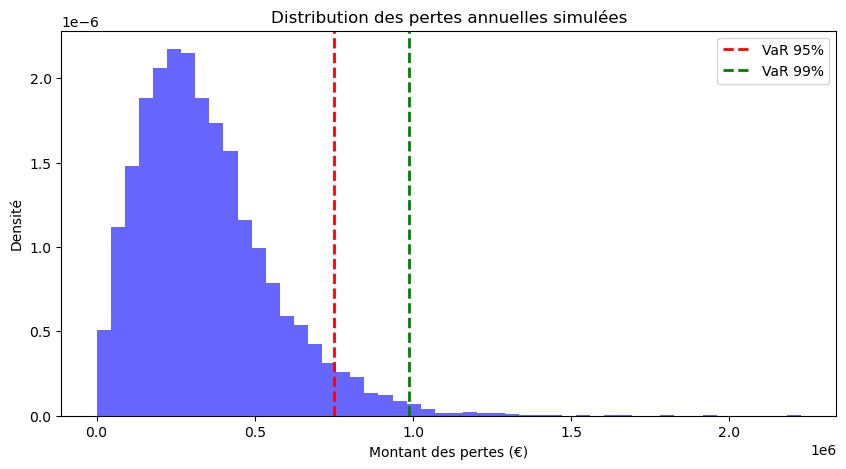

Perte moyenne attendue : 345,707.72 €
Value at Risk (VaR) à 95% : 748,996.58 €
Value at Risk (VaR) à 99% : 988,657.79 €


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
N = 10000  # Nombre de simulations Monte Carlo (10 000 années)
lambda_freq = 5  # Nombre moyen d'événements par an (loi de Poisson)
mu = np.log(50000)  # Moyenne logarithmique des pertes (loi Log-normale)
sigma = 0.8  # Dispersion des pertes

# Stocker les pertes totales pour chaque simulation
pertes_totales = []

# Boucle pour générer 10 000 simulations
for _ in range(N):
    nb_pertes = np.random.poisson(lambda_freq)  # Nombre d'événements
    if nb_pertes > 0:
        montants_pertes = np.random.lognormal(mu, sigma, nb_pertes)  # Générer les montants
        perte_annuelle = montants_pertes.sum()  # Somme des pertes de l'année
    else:
        perte_annuelle = 0  # Aucune perte cette année

    pertes_totales.append(perte_annuelle)  # Ajouter aux résultats

# Convertir en tableau numpy pour analyse rapide
pertes_totales = np.array(pertes_totales)

# Calcul des indicateurs de risque (VaR)
var_95 = np.percentile(pertes_totales, 95)  # Value at Risk à 95%
var_99 = np.percentile(pertes_totales, 99)  # Value at Risk à 99%

#  Affichage de la distribution des pertes simulées
plt.figure(figsize=(10,5))
plt.hist(pertes_totales, bins=50, density=True, alpha=0.6, color='b')
plt.axvline(var_95, color='r', linestyle='dashed', linewidth=2, label="VaR 95%")
plt.axvline(var_99, color='g', linestyle='dashed', linewidth=2, label="VaR 99%")
plt.title("Distribution des pertes annuelles simulées")
plt.xlabel("Montant des pertes (€)")
plt.ylabel("Densité")
plt.legend()
plt.show()

# Affichage des résultats
print(f"Perte moyenne attendue : {np.mean(pertes_totales):,.2f} €")
print(f"Value at Risk (VaR) à 95% : {var_95:,.2f} €")
print(f"Value at Risk (VaR) à 99% : {var_99:,.2f} €")
